In [1]:
import os
import syllables
import string
from datasets import load_dataset
from mlx_tune import FastLanguageModel, SFTTrainer, SFTConfig
from transformers import TrainingArguments, set_seed
from mlx_lm import generate
from mlx_tune.chat_templates import get_chat_template, standardize_sharegpt

In [2]:
set_seed(42)

In [3]:
dataset = load_dataset("json", data_files="../../data/processed/haikus_dataset.json", split="train")

In [4]:
dataset

Dataset({
    features: ['conversations'],
    num_rows: 500
})

In [5]:
dataset = standardize_sharegpt(dataset)

In [6]:
max_seq_length = 2048

In [7]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "google/gemma-3-270m",
    max_seq_length = max_seq_length,
    load_in_4bit = False
)

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

In [8]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)

In [9]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = []
    for convo in convos:
        formatted = tokenizer.apply_chat_template(
            convo,
            tokenize=False,
            add_generation_prompt=False
        )
        
        
        texts.append(formatted)
    return {"text": texts}

In [10]:
dataset = dataset.map(formatting_prompts_func, batched = True)
print(f"✅ Preprocessing complete. Samples formatted: {len(dataset)}")

✅ Preprocessing complete. Samples formatted: 500


In [11]:
dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

In [12]:
print(f"Training on: {len(train_dataset)} | Evaluating on: {len(eval_dataset)}")

Training on: 450 | Evaluating on: 50


In [13]:
def count_syllables_line(line):
    clean = line.translate(str.maketrans('', '', string.punctuation))
    return sum(syllables.estimate(word) for word in clean.split())

In [14]:
def evaluate_haiku(text):
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    if len(lines) != 3:
        return [0, 0, 0], False
    counts = [count_syllables_line(l) for l in lines]
    is_perfect = (counts == [5, 7, 5])
    return counts, is_perfect

In [15]:
import pandas as pd

def run_internal_eval_detailed(model, tokenizer, test_samples):
    
    results_list = []

    for sample in test_samples:
        user_prompt = sample['messages'][0]['content']

        eval_messages = [
             {"role": "user", "content": user_prompt}
        ]
        
        prompt = tokenizer.apply_chat_template(
            eval_messages,
            tokenize=False,
            add_generation_prompt=True
        )

        response = generate(model, tokenizer, prompt=prompt, max_tokens=64)

        haiku = response.split("<end_of_turn>")[0].strip()

        counts, is_perfect = evaluate_haiku(haiku)
        total_syllables = sum(counts)
        # print(f"Topic: {user_prompt} | Pattern: {counts} | Perfect: {is_perfect}")

        results_list.append({
            "topic": user_prompt,
            "counts": counts,
            "total": total_syllables,
            "is_perfect": is_perfect,
            "error_dist": abs(total_syllables - 17)
        })
        
    return pd.DataFrame(results_list)

In [16]:
# for name, module in model.named_modules():
#     if "proj" in name:
#         print(name)

In [17]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, 
    target_modules = ["self_attn.q_proj", "self_attn.k_proj", "self_attn.v_proj", 
                      "self_attn.o_proj", "mlp.gate_proj", "mlp.up_proj", "mlp.down_proj"],
    lora_alpha = 32,
    lora_dropout = 0, 
    bias = "none",    
)

LoRA configuration set: rank=16, alpha=32, modules=['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj', 'self_attn.o_proj', 'mlp.gate_proj', 'mlp.up_proj', 'mlp.down_proj'], dropout=0


In [18]:
training_config = SFTConfig(
    output_dir = "mlx_outputs",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    max_steps = 2000,             
    max_length = max_seq_length,
    learning_rate = 2e-4,
    logging_steps = 15,
    # lr_scheduler_type = "constant",
    dataset_text_field = "text",       
)

In [19]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [20]:
trainer = SFTTrainer(
    model = model,
    processing_class = tokenizer,      
    train_dataset = train_dataset,
    args = training_config,            
)

Trainer initialized:
  Output dir: mlx_outputs
  Adapter path: mlx_outputs/adapters
  Learning rate: 0.0002
  Iterations: 2000
  Batch size: 2
  LoRA r=16, alpha=32
  Native training: True
  LR scheduler: cosine
  Grad checkpoint: False


In [21]:
print("--- TRAINER INPUT CHECK ---")
print(train_dataset[0]['text'][:100])

--- TRAINER INPUT CHECK ---
<start_of_turn>user
What is the capital of Austria?<end_of_turn>
<start_of_turn>model
Vienna stands 


In [22]:
print("🍏 Launching Metal-accelerated fine-tuning loop on your M1 GPU...")
trainer.train()
print("✅ Training sequence completely run!")

🍏 Launching Metal-accelerated fine-tuning loop on your M1 GPU...
Starting Fine-Tuning

[Using Native MLX Training]

Applying LoRA adapters...
Applying LoRA to 18 layers: {'rank': 16, 'scale': 2.0, 'dropout': 0, 'keys': ['mlp.down_proj', 'mlp.gate_proj', 'mlp.up_proj', 'self_attn.k_proj', 'self_attn.o_proj', 'self_attn.q_proj', 'self_attn.v_proj']}
✓ LoRA applied successfully to 18 layers
  Trainable LoRA parameters: 252
Preparing training data...
  Detected format: text
✓ Prepared 450 training samples
  Saved to: mlx_outputs/train.jsonl
✓ Created validation set (copied from train)

Training configuration:
  Iterations: 2000
  Batch size: 2
  Learning rate: 0.0002
  LR scheduler: cosine
  Grad checkpoint: False
  Adapter file: mlx_outputs/adapters/adapters.safetensors

Loaded 450 training samples, 450 validation samples
Starting training loop...
Starting training..., iters: 2000


Calculating loss...: 100%|█| 5/5 [00:00<00:00, 1

Iter 1: Val loss 8.370, Val took 0.471s


Iter 15: Train loss 4.539, Learning Rate 2.000e-04, It/sec 5.849, Tokens/sec 451.175, Trained Tokens 1157, Peak mem 0.990 GB
Iter 30: Train loss 2.630, Learning Rate 1.999e-04, It/sec 6.013, Tokens/sec 462.616, Trained Tokens 2311, Peak mem 0.990 GB
Iter 45: Train loss 2.460, Learning Rate 1.998e-04, It/sec 6.046, Tokens/sec 466.367, Trained Tokens 3468, Peak mem 0.990 GB
Iter 60: Train loss 2.304, Learning Rate 1.996e-04, It/sec 6.066, Tokens/sec 449.288, Trained Tokens 4579, Peak mem 0.990 GB
Iter 75: Train loss 2.277, Learning Rate 1.993e-04, It/sec 6.101, Tokens/sec 456.338, Trained Tokens 5701, Peak mem 0.990 GB
Iter 90: Train loss 2.387, Learning Rate 1.990e-04, It/sec 6.131, Tokens/sec 463.107, Trained Tokens 6834, Peak mem 0.990 GB
Iter 100: Saved adapter weights to mlx_outputs/adapters/adapters.safetensors and mlx_outputs/adapters/0000100_adapters.safetensors.
Iter 105: Train loss 2.082, Learning Rate 1.987e-04, It/sec 6.107, Tokens/sec 465.781, Trained Tokens 7978, Peak mem 1

Calculating loss...: 100%|█| 5/5 [00:00<00:00, 1

...

Iter 1800: Val loss 0.167, Val took 0.377s


Iter 1800: Train loss 0.180, Learning Rate 4.943e-06, It/sec 6.022, Tokens/sec 459.666, Trained Tokens 136504, Peak mem 1.006 GB
Iter 1800: Saved adapter weights to mlx_outputs/adapters/adapters.safetensors and mlx_outputs/adapters/0001800_adapters.safetensors.
Iter 1815: Train loss 0.172, Learning Rate 4.238e-06, It/sec 6.077, Tokens/sec 446.057, Trained Tokens 137605, Peak mem 1.006 GB
Iter 1830: Train loss 0.165, Learning Rate 3.586e-06, It/sec 6.038, Tokens/sec 477.437, Trained Tokens 138791, Peak mem 1.006 GB
Iter 1845: Train loss 0.175, Learning Rate 2.987e-06, It/sec 6.009, Tokens/sec 466.302, Trained Tokens 139955, Peak mem 1.006 GB
Iter 1860: Train loss 0.168, Learning Rate 2.443e-06, It/sec 6.135, Tokens/sec 457.695, Trained Tokens 141074, Peak mem 1.006 GB
Iter 1875: Train loss 0.172, Learning Rate 1.952e-06, It/sec 6.034, Tokens/sec 459.352, Trained Tokens 142216, Peak mem 1.006 GB
Iter 1890: Train loss 0.170, Learning Rate 1.516e-06, It/sec 6.023, Tokens/sec 453.737, Train

Calculating loss...: 100%|█| 5/5 [00:00<00:00, 1

Iter 2000: Val loss 0.163, Val took 0.376s


Iter 2000: Train loss 0.162, Learning Rate 1.252e-10, It/sec 18.310, Tokens/sec 457.749, Trained Tokens 151654, Peak mem 1.006 GB
Iter 2000: Saved adapter weights to mlx_outputs/adapters/adapters.safetensors and mlx_outputs/adapters/0002000_adapters.safetensors.
Saved final weights to mlx_outputs/adapters/adapters.safetensors.
  Adapter config saved to: mlx_outputs/adapters/adapter_config.json

Training Complete!
  Adapters saved to: mlx_outputs/adapters
✅ Training sequence completely run!


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_results(df):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    sns.histplot(df['total'], bins=10, color='skyblue', kde=True)
    plt.axvline(17, color='red', linestyle='--', label='Perfect (17)')
    plt.title("Syllable Count Distribution")
    plt.legend()


    plt.subplot(1, 2, 2)
    
    df['is_perfect'].value_index = ["Failure", "Perfect"]
    sns.countplot(x='is_perfect', data=df,  hue='is_perfect', palette='viridis', legend=False)
    plt.title(f"Accuracy: {(df['is_perfect'].mean()*100):.1f}%")

    plt.tight_layout()
    plt.show()

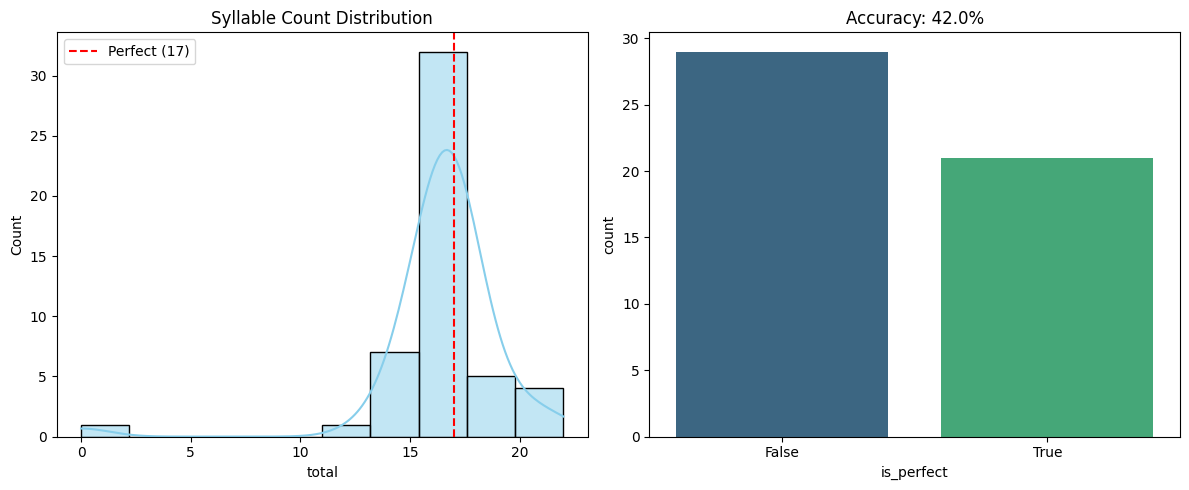

In [24]:
eval_df = run_internal_eval_detailed(model, tokenizer, eval_dataset)

visualize_results(eval_df)

In [25]:
eval_df["counts"]

0     [5, 7, 5]
1     [5, 7, 5]
2     [5, 7, 5]
3     [5, 6, 7]
4     [5, 5, 5]
5     [5, 7, 5]
6     [5, 9, 5]
7     [3, 7, 5]
8     [6, 8, 6]
9     [5, 7, 5]
10    [4, 7, 5]
11    [0, 0, 0]
12    [8, 9, 5]
13    [5, 6, 5]
14    [5, 7, 6]
15    [5, 5, 5]
16    [5, 7, 5]
17    [3, 7, 3]
18    [5, 6, 7]
19    [5, 7, 4]
20    [3, 7, 6]
21    [5, 6, 4]
22    [5, 7, 5]
23    [4, 6, 4]
24    [5, 7, 5]
25    [5, 7, 5]
26    [5, 7, 5]
27    [4, 8, 4]
28    [5, 6, 5]
29    [6, 6, 5]
30    [6, 7, 7]
31    [5, 7, 5]
32    [5, 6, 5]
33    [5, 7, 5]
34    [5, 7, 4]
35    [5, 7, 5]
36    [6, 5, 5]
37    [5, 7, 5]
38    [5, 5, 5]
39    [5, 7, 5]
40    [5, 7, 5]
41    [5, 8, 5]
42    [5, 6, 4]
43    [5, 7, 5]
44    [5, 7, 5]
45    [5, 7, 5]
46    [5, 7, 5]
47    [5, 7, 5]
48    [5, 6, 5]
49    [4, 9, 8]
Name: counts, dtype: object

In [34]:
!pip install mlx-lm

  Using cached regex-2026.5.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.4/588.4 kB 10.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 MB 2.1 MB/s  0:00:26 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 1.3 MB/s  0:00:08 eta 0:00:010:00:01
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached regex-2026.5.9-cp314-cp314-macosx_11_0_arm64.whl (289 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.4 MB/s  0:00:001.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [mlx-lm]━━ 10/11 [mlx-lm]transformers]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [35]:
!python -m mlx_lm fuse --model google/gemma-3-270m --adapter-path mlx_outputs/adapters --save-path ../../models/gemmaiku-3-270m

Loading pretrained model
Fetching 8 files: 100%|███████████████████████| 8/8 [00:00<00:00, 12197.18it/s]
Download complete: : 0.00B [00:00, ?B/s]              


In [ ]:
from mlx_lm import load, generate

model, tokenizer = load("../../models/gemmaiku-3-270m")

while True:
    user_input = input("Topic: ")
    prompt = f"<start_of_turn>user\n{user_input}<end_of_turn>\n<start_of_turn>model\n"

    response = generate(model, tokenizer, prompt=prompt, max_tokens=64)

    print(response.split("<end_of_turn>")[0].strip())

Topic:  I want to become a hardware engineer


Learn to code,
Design and test the world,
Mach up every problem.
